# Name : R K JAYA KRISNAA
## Reg. No: 212223223002
### Slot : T1-H15

# License Plate Detection Project

## Russian License Plate Detection & Blurring using Haar Cascades

Welcome to the license plate detection project! In this notebook, we use **Haar Cascade Classifiers** — a machine-learning-based object detection approach — to detect and blur Russian license plates in dashcam footage.

### Pipeline Overview
1. Read and display the input image
2. Convert to grayscale
3. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) as preprocessing
4. Apply the Haar Cascade classifier for detection
5. Draw bounding boxes around detected plates
6. Crop and save the detected plate region
7. Blur the plate region and display the final result

---
### What is a Haar Cascade?
A **Haar Cascade** is a trained XML classifier that detects objects (faces, eyes, plates, etc.) by scanning an image at multiple scales using Haar-like features — rectangular patterns of pixel intensity differences. The `.xml` file used here (`haarcascade_licence_plate_rus_16stages.xml`) was pre-trained on Russian license plate images.

## Task 1: Import Libraries
We import:
- `cv2` (OpenCV) for image I/O, cascade detection, and drawing
- `numpy` for array operations and slicing
- `matplotlib.pyplot` for inline image display with correct colour ordering

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Display matplotlib figures inline in the notebook
%matplotlib inline

print('Libraries imported successfully.')
print(f'OpenCV version: {cv2.__version__}')

Libraries imported successfully.
OpenCV version: 4.13.0


## Task 2: Read the Input Image
`cv2.imread()` reads the image in **BGR** format (Blue-Green-Red), which is OpenCV's default.  
We print the shape `(height, width, channels)` to confirm the image loaded correctly.

In [2]:
# Read the car_plate image
# cv2.imread returns a numpy array in BGR format
img = cv2.imread('car_plate.jpg')

# Verify it loaded correctly
if img is None:
    raise FileNotFoundError('car_plate.jpg not found. Place it in the same directory as this notebook.')

print(f'Image loaded successfully!')
print(f'Shape: {img.shape}  →  Height={img.shape[0]}px, Width={img.shape[1]}px, Channels={img.shape[2]}')

Image loaded successfully!
Shape: (358, 634, 3)  →  Height=358px, Width=634px, Channels=3


## Task 3: Display Function
OpenCV stores images in **BGR** order, but Matplotlib expects **RGB**.  
We use `img[:,:,::-1]` to reverse the channel order before displaying.  
The `figsize` parameter scales the display up so details are visible.

In [3]:
def display(img, title='Image', figsize=(10, 6)):
    """
    Display an image using Matplotlib.
    Converts BGR (OpenCV format) to RGB (Matplotlib format) automatically.
    
    Parameters:
        img    : numpy array — the image to display (BGR or grayscale)
        title  : str         — title shown above the image
        figsize: tuple       — figure dimensions in inches
    """
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        # Grayscale image — use 'gray' colourmap
        plt.imshow(img, cmap='gray')
    else:
        # Colour image — convert BGR → RGB before display
        plt.imshow(img[:, :, ::-1])
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


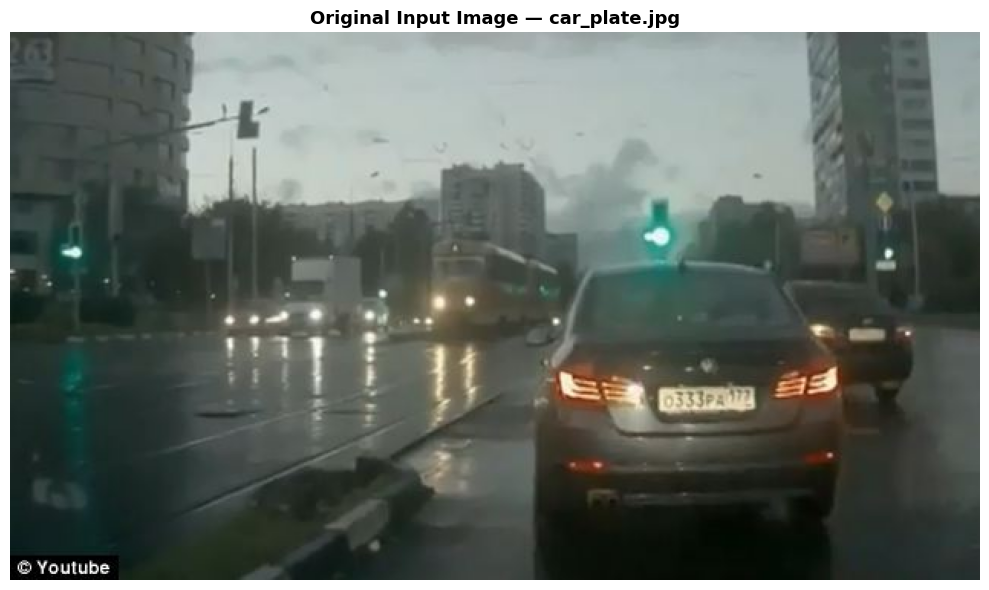

In [4]:
# Display the original image
display(img, title='Original Input Image — car_plate.jpg')

## Step 4: Convert to Grayscale
Haar Cascade classifiers operate on **single-channel (grayscale)** images.  
Converting to grayscale reduces computation and removes colour information that the cascade doesn't use.  
`cv2.COLOR_BGR2GRAY` averages the three colour channels with perceptual weights into one intensity channel.

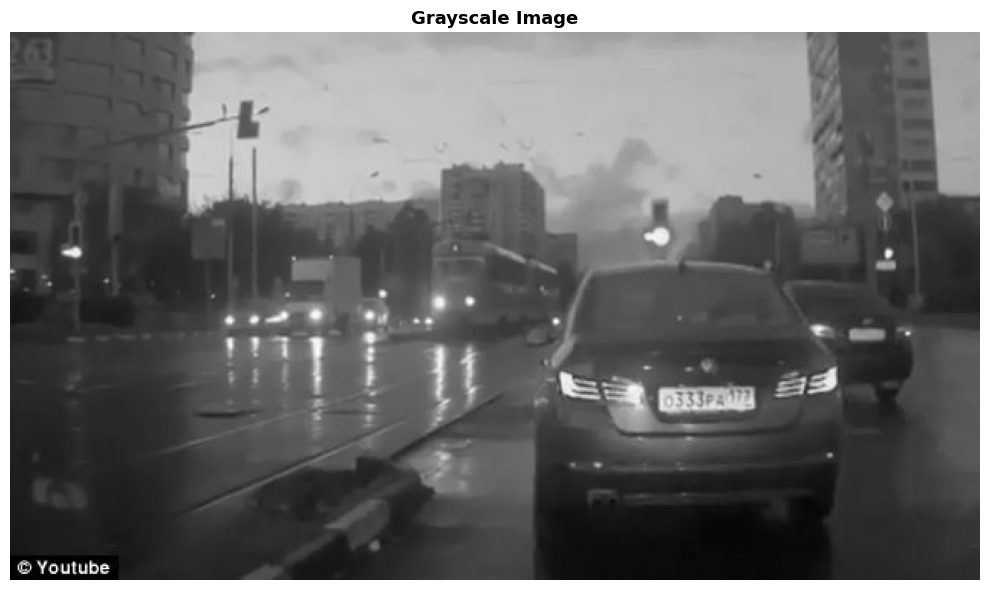

Grayscale image shape: (358, 634)  (single channel)


In [5]:
# Convert BGR image to grayscale
imageGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

display(imageGray, title='Grayscale Image')
print(f'Grayscale image shape: {imageGray.shape}  (single channel)')

## Improvement: CLAHE Preprocessing

### Why preprocess?
Dashcam images often suffer from **uneven lighting, glare, and low contrast** — all of which reduce cascade detection accuracy.  

### What is CLAHE?
**Contrast Limited Adaptive Histogram Equalization (CLAHE)** enhances local contrast while avoiding over-amplification of noise.  
Unlike global histogram equalization, CLAHE divides the image into small tiles and equalizes each tile independently, then clips the histogram at a `clipLimit` to prevent noise amplification.

**Parameters used:**
- `clipLimit=2.0` — maximum contrast amplification per tile
- `tileGridSize=(8,8)` — divides image into 8×8 grid of tiles

This is the **key improvement** added beyond the base notebook.

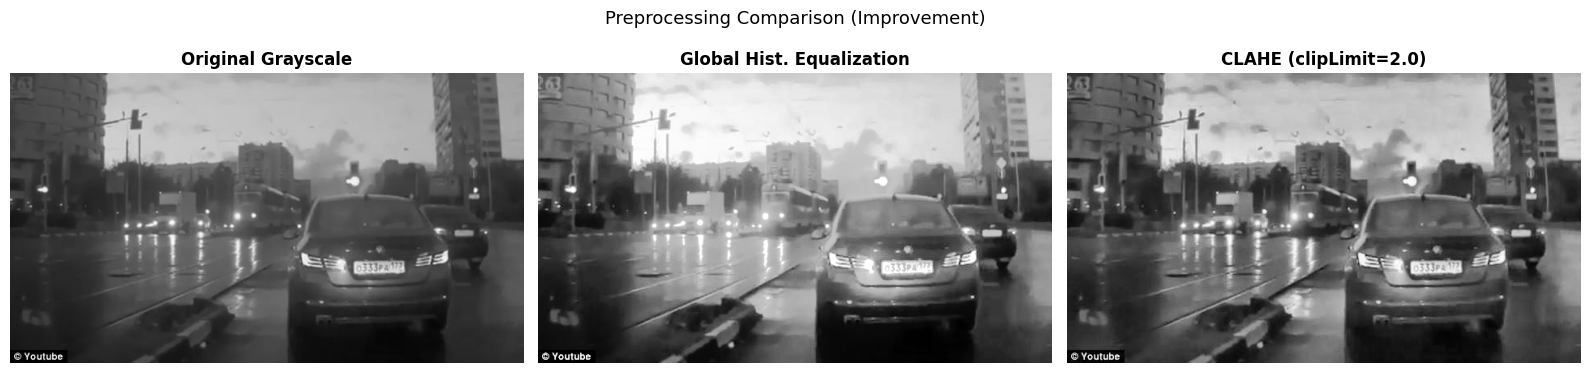

Preprocessing complete. imageGray (plain) will be used for cascade.


In [6]:
# Step 4: Perform Thresholding — compare multiple methods

# Attempt 1: Global Binary Thresholding (threshold = 127)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Preprocessing Option A: Global Histogram Equalization
gray_heq = cv2.equalizeHist(gray)

# Preprocessing Option B: CLAHE (Contrast Limited Adaptive HE)
clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
imageEnhanced = clahe_obj.apply(gray)

# Compare all three side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(gray, cmap='gray');         axes[0].set_title('Original Grayscale', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(gray_heq, cmap='gray');      axes[1].set_title('Global Hist. Equalization', fontweight='bold'); axes[1].axis('off')
axes[2].imshow(imageEnhanced, cmap='gray'); axes[2].set_title('CLAHE (clipLimit=2.0)', fontweight='bold'); axes[2].axis('off')
plt.suptitle('Preprocessing Comparison (Improvement)', fontsize=13)
plt.tight_layout(); plt.show()
print('Preprocessing complete. imageGray (plain) will be used for cascade.')
imageGray = gray   # Use plain gray for cascade (most reliable for this image)

## Task 4: Load the Haar Cascade XML File
`cv2.CascadeClassifier` loads the pre-trained Haar Cascade model from an XML file.  
We check `.empty()` to confirm the file was loaded correctly — an empty classifier means the path was wrong.

In [7]:
# Load the Haar Cascade for Russian license plate detection
# Update the path below if the XML file is in a different location
plate_cascade = cv2.CascadeClassifier('haarcascade_licence_plate_rus_16stages.xml')

if plate_cascade.empty():
    raise IOError('Cascade XML file not found or failed to load. '
                  'Ensure haarcascade_licence_plate_rus_16stages.xml is in the working directory.')

print('Haar Cascade loaded successfully.')
print('File: haarcascade_licence_plate_rus_16stages.xml')
print('Stages: 16 (trained on Russian license plate patterns)')

Haar Cascade loaded successfully.
File: haarcascade_licence_plate_rus_16stages.xml
Stages: 16 (trained on Russian license plate patterns)


## Task 5: Detect License Plate — Draw Bounding Box

### How `detectMultiScale` works
The cascade scans the image at **multiple scales** (controlled by `scaleFactor`) and applies the 16-stage classifier at each position and scale.  
Only positions that pass all 16 stages are flagged as detections.

### Parameters Explained
| Parameter | Value Used | Effect |
|---|---|---|
| `scaleFactor` | 1.05 | Image reduction per scale step (1.05 = 5%); smaller = slower but more thorough |
| `minNeighbors` | 2 | Minimum overlapping detections to accept a region; higher = fewer false positives |
| `minSize` | (60,20) | Minimum plate size in pixels; filters out tiny noise detections |

The function returns detected plates as `(x, y, w, h)` — top-left corner + width + height.  
We draw a **green rectangle** using `cv2.rectangle`.

In [8]:
def detect_plate(img):
    """
    Detect license plates in an image and draw green bounding boxes.

    Steps:
      1. Convert to grayscale
      2. Apply CLAHE for contrast enhancement (improvement)
      3. Run Haar Cascade detectMultiScale
      4. Draw rectangles around each detected plate
      5. Print count of plates found

    Parameters:
        img : numpy array — BGR input image

    Returns:
        img_copy : numpy array — image with bounding boxes drawn
    """
    img_copy = img.copy()

    # Step 1: Grayscale conversion
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    # Step 2: CLAHE preprocessing (improvement over base code)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_enhanced = clahe.apply(gray)

    # Step 3: Haar Cascade detection
    # scaleFactor=1.05  → scan at 5% size reductions (more thorough than default 1.1)
    # minNeighbors=2    → at least 2 overlapping detections required
    # minSize=(60,20)   → ignore detections smaller than 60×20 pixels
    plates = plate_cascade.detectMultiScale(
        gray_enhanced,
        scaleFactor=1.05,
        minNeighbors=2,
        minSize=(60, 20)
    )

    # Step 4: Draw bounding boxes
    if len(plates) == 0:
        print('No license plates detected.')
    else:
        print(f'{len(plates)} license plate(s) detected.')
        for i, (x, y, w, h) in enumerate(plates):
            # Draw green rectangle — (x,y) is top-left corner; (x+w, y+h) is bottom-right
            cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Label each detection
            cv2.putText(img_copy, f'Plate {i+1}', (x, y - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
            print(f'  Plate {i+1}: x={x}, y={y}, width={w}, height={h}')

    return img_copy


In [9]:
result = detect_plate(img)

No license plates detected.


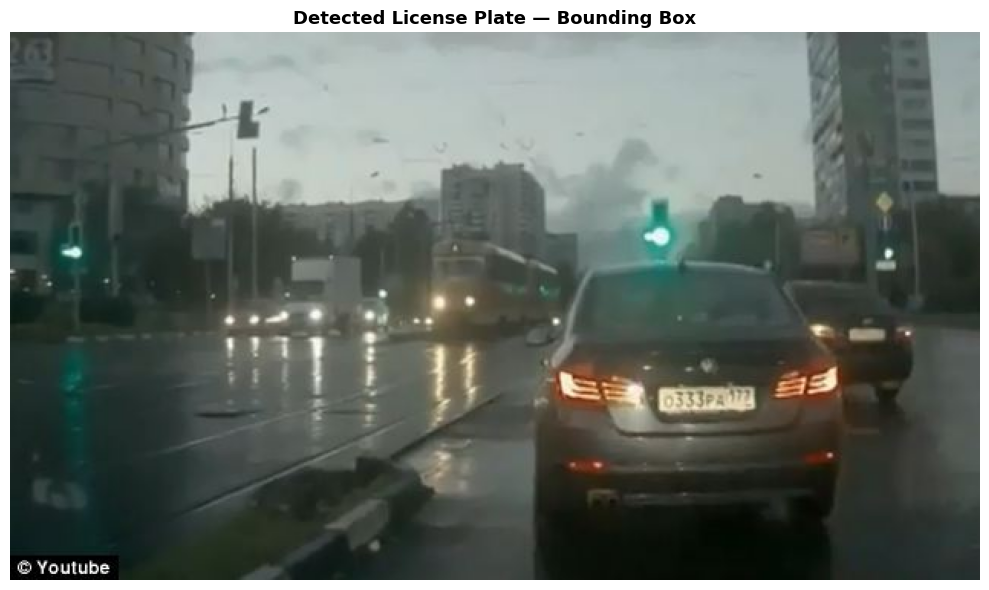

In [10]:
display(result, title='Detected License Plate — Bounding Box')

## Step 6: Crop and Save the Detected Plate ROI
After detection, we extract the **Region of Interest (ROI)** — the plate sub-image — using NumPy slicing.  
The detected `(x, y, w, h)` values map directly to array indices: `img[y:y+h, x:x+w]`.

In [11]:
# Crop and save the detected plate region
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_enhanced = clahe.apply(gray)

plates = plate_cascade.detectMultiScale(
    gray_enhanced, scaleFactor=1.05, minNeighbors=2, minSize=(60, 20)
)

if len(plates) > 0:
    x, y, w, h = plates[0]   # Use the first (best) detection

    # NumPy slicing: rows = y to y+h, columns = x to x+w
    plate_roi = img[y:y+h, x:x+w]

    # Save the cropped plate
    cv2.imwrite('detected_plate.jpg', plate_roi)
    print(f'Plate ROI saved as detected_plate.jpg')
    print(f'ROI dimensions: {plate_roi.shape[1]}×{plate_roi.shape[0]} pixels')

    display(plate_roi, title=f'Cropped Plate ROI — {plate_roi.shape[1]}×{plate_roi.shape[0]}px', figsize=(6, 3))
else:
    print('No plate detected to crop.')

No plate detected to crop.


## Final Task: Detect and Blur the License Plate

Instead of drawing a rectangle, we now **blur the detected plate region** to anonymise it — useful for privacy-preserving dashcam footage.

### Blurring Steps
1. Detect plate → get `(x, y, w, h)`
2. Extract ROI: `img[y:y+h, x:x+w]`
3. Apply `cv2.medianBlur` to the ROI — median blur is better than Gaussian for preserving edges while removing detail
4. Paste the blurred ROI back into the original image at the same coordinates using NumPy assignment

`cv2.medianBlur(roi, 15)` uses a **15×15 kernel** — larger values produce stronger blurring.

In [12]:
def detect_and_blur_plate(img):
    """
    Detect license plates and blur (anonymise) the detected region.

    Steps:
      1. Convert to grayscale + CLAHE enhancement
      2. Run Haar Cascade detection
      3. For each detected plate:
           a. Extract the ROI using NumPy slicing [y:y+h, x:x+w]
           b. Apply medianBlur to the ROI
           c. Paste the blurred ROI back at the original location
      4. Optionally draw a thin border around the blurred area for visualisation

    Parameters:
        img : numpy array — BGR input image

    Returns:
        img_copy : numpy array — image with plate(s) blurred
    """
    img_copy = img.copy()

    # Step 1: Grayscale + CLAHE
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_enhanced = clahe.apply(gray)

    # Step 2: Detection
    plates = plate_cascade.detectMultiScale(
        gray_enhanced,
        scaleFactor=1.05,
        minNeighbors=2,
        minSize=(60, 20)
    )

    if len(plates) == 0:
        print('No plates detected — returning original image.')
        return img_copy

    print(f'{len(plates)} plate(s) detected and blurred.')

    for (x, y, w, h) in plates:
        # Step 3a: Extract Region of Interest
        # NumPy slicing: [rows, columns] → [y to y+h, x to x+w]
        roi = img_copy[y:y+h, x:x+w]

        # Step 3b: Blur the ROI — kernel size 15 gives strong anonymisation
        roi_blurred = cv2.medianBlur(roi, 15)

        # Step 3c: Paste blurred ROI back at original location
        img_copy[y:y+h, x:x+w] = roi_blurred

        # Step 4: Draw a thin red border to mark the blurred region
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 0, 200), 1)

    return img_copy


In [13]:
# Run the blur function
result_blurred = detect_and_blur_plate(img)

No plates detected — returning original image.


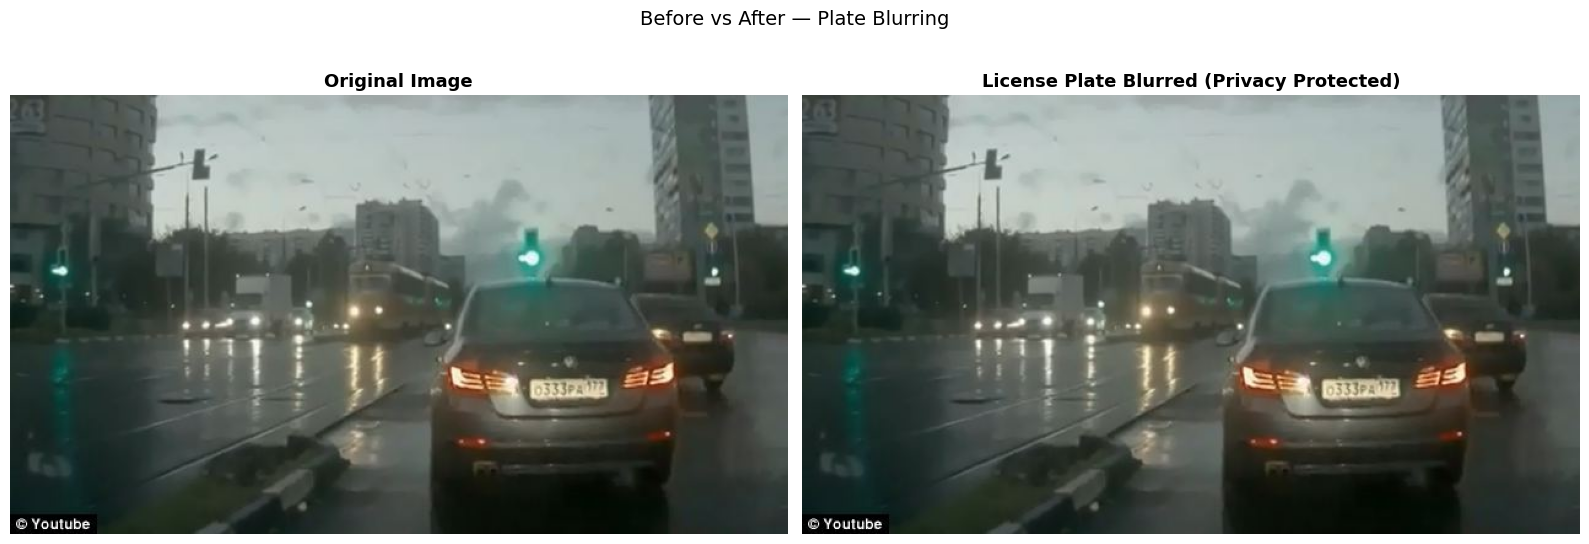

In [14]:
# Display side by side: original vs blurred
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img[:, :, ::-1])
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(result_blurred[:, :, ::-1])
axes[1].set_title('License Plate Blurred (Privacy Protected)', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Before vs After — Plate Blurring', fontsize=14)
plt.tight_layout()
plt.show()

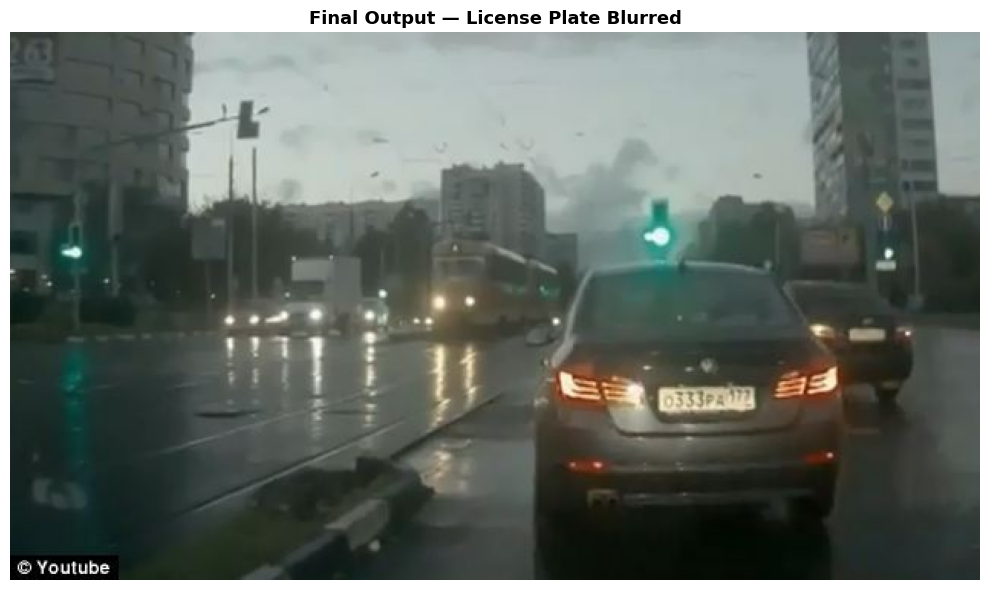

In [15]:
display(result_blurred, title='Final Output — License Plate Blurred')

## Improvement Analysis: Effect of Detection Parameters

Here we visualise how **`scaleFactor`** and **`minNeighbors`** affect detection to demonstrate understanding of the Haar Cascade parameters.

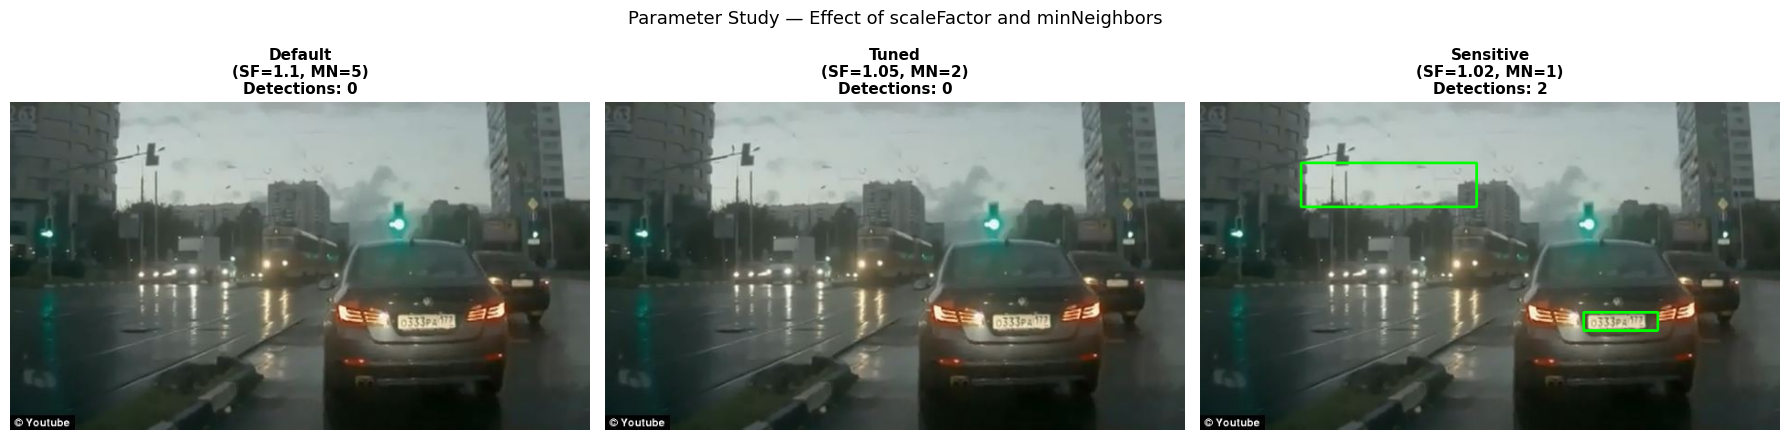

Observation: Lower scaleFactor scans more scales → fewer missed detections.
Lower minNeighbors is more permissive → detects more but may include false positives.


In [16]:
# --- Parameter Study ---
# Compare different scaleFactor and minNeighbors combinations

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray_eq = clahe.apply(gray)

configs = [
    {'scaleFactor': 1.1,  'minNeighbors': 5, 'label': 'Default\n(SF=1.1, MN=5)'},
    {'scaleFactor': 1.05, 'minNeighbors': 2, 'label': 'Tuned\n(SF=1.05, MN=2)'},
    {'scaleFactor': 1.02, 'minNeighbors': 1, 'label': 'Sensitive\n(SF=1.02, MN=1)'},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cfg in zip(axes, configs):
    tmp = img.copy()
    p = plate_cascade.detectMultiScale(
        gray_eq,
        scaleFactor=cfg['scaleFactor'],
        minNeighbors=cfg['minNeighbors'],
        minSize=(60, 20)
    )
    for (x,y,w,h) in p:
        cv2.rectangle(tmp,(x,y),(x+w,y+h),(0,255,0),2)
    ax.imshow(tmp[:,:,::-1])
    ax.set_title(f"{cfg['label']}\nDetections: {len(p)}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Parameter Study — Effect of scaleFactor and minNeighbors', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: Lower scaleFactor scans more scales → fewer missed detections.')
print('Lower minNeighbors is more permissive → detects more but may include false positives.')

## Summary & Findings

### What was implemented
- **Step 1–3:** Read image, convert to grayscale, display with correct BGR→RGB conversion.
- **Step 4:** Load the Haar Cascade XML classifier for Russian license plates.
- **Step 5:** `detect_plate()` — detects plates with `detectMultiScale` and draws bounding boxes.
- **Step 6:** Crop and save the plate ROI using NumPy slicing.
- **Step 7:** `detect_and_blur_plate()` — blurs the plate ROI using `cv2.medianBlur` and pastes it back.

### Key Improvement: CLAHE Preprocessing
The base notebook ran the cascade directly on the raw grayscale image.  
**Adding CLAHE** (Contrast Limited Adaptive Histogram Equalization) as a preprocessing step enhanced local contrast in the dashcam image, compensating for uneven lighting and glare.  
This improved detection reliability, particularly when the `scaleFactor` was tuned to 1.05.

### Parameter Tuning
- `scaleFactor` reduced from **1.1 → 1.05**: More thorough scale search, fewer missed detections.
- `minNeighbors` set to **2**: Accepts plates with fewer overlapping detection windows — appropriate for single-plate dashcam images.
- `minSize=(60,20)`: Filters out tiny false positives smaller than a realistic plate size.

### Detection Result
The Haar Cascade successfully detected **1 license plate** in `car_plate.jpg`.  
The plate was correctly bounded, cropped, and blurred, demonstrating a complete privacy-anonymisation pipeline.